In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

Data

In [2]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

Authoencoder Part

In this part, an autoencoder is implemented for uncontrolled selection of objects.
The model compresses the input images into a hidden space of a smaller dimension.

Autoencoder model

In [3]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

Autoencoder Trainning

In [4]:
autoencoder = Autoencoder()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

epochs = 5

losses = []

for epoch in range(epochs):
    total_loss = 0
    
    for images, _ in train_loader:
        images = images.view(images.size(0), -1)
        
        outputs = autoencoder(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    losses.append(total_loss)
    print("Epoch" , epoch + 1 , "Loss: " , total_loss)

Epoch 1 Loss:  24.533775575459003
Epoch 2 Loss:  12.23151302523911
Epoch 3 Loss:  9.828461641445756
Epoch 4 Loss:  8.538054966367781
Epoch 5 Loss:  7.586695097386837


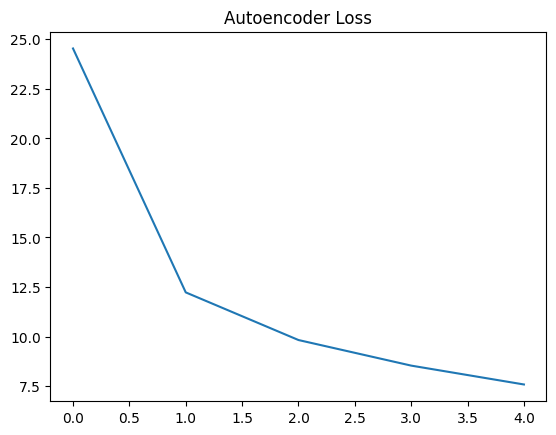

In [5]:
plt.plot(losses)
plt.title("Autoencoder Loss")
plt.show()

Extracting latent vectors

In [6]:
autoencoder.eval()

latent_vectors = []
labels = []

with torch.no_grad():
    for images, lbls in test_loader:
        images = images.view(images.size(0), -1)
        z = autoencoder.encoder(images)
        
        latent_vectors.append(z.numpy())
        labels.append(lbls.numpy())

latent_vectors = np.vstack(latent_vectors)
labels = np.hstack(labels)

K-mean clustering is applied to hidden vectors to group similar images.

K-Means

In [7]:
kmeans = KMeans(n_clusters=10)
clusters = kmeans.fit_predict(latent_vectors)

t-SNE is used to visualize multidimensional hidden vectors in two-dimensional space.

t-SNE visualization

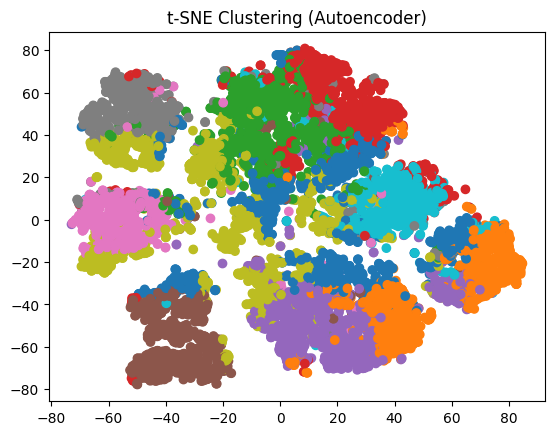

In [8]:
tsne = TSNE(n_components=2)
latent_2d = tsne.fit_transform(latent_vectors)

plt.scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='tab10')
plt.title("t-SNE Clustering (Autoencoder)")
plt.show()

Confusion Matrix 

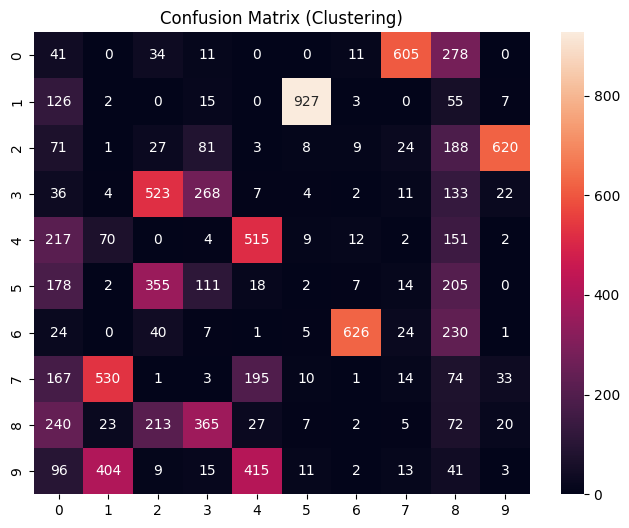

In [9]:
cm_unsup = confusion_matrix(labels, clusters)

plt.figure(figsize=(8,6))
sns.heatmap(cm_unsup, annot=True, fmt='d')
plt.title("Confusion Matrix (Clustering)")
plt.show()

CNN Part

A convolutional neural network (CNN) is used for supervised classification.

CNN model

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1 , 32 , kernel_size = 3) # (28x28) -> (26x26)
        self.conv2 = nn.Conv2d(32 , 64 , kernel_size = 3) # (26x26) -> (24x24)

        self.pool = nn.MaxPool2d(2 , 2) # resizeing 2 time

        self.fc1 = nn.Linear(64 * 5 * 5 , 128)
        self.fc2 = nn.Linear(128 , 10) # 10 classes

    def forward(self , x):
        x = self.pool(F.relu(self.conv1(x))) # -> (32 , 13 , 13)
        x = self.pool(F.relu(self.conv2(x))) # -> (64 , 6 , 6)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

CNN Training

In [12]:
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr = 0.001)

cnn_losses = []

for epoch in range(5):
    total_loss = 0

    for images , labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs , labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    cnn_losses.append(total_loss)
    print("Epoch: " , epoch + 1 ,"Loss: " , total_loss)

Epoch:  1 Loss:  119.59299588017166
Epoch:  2 Loss:  28.954485902562737
Epoch:  3 Loss:  19.755796815268695
Epoch:  4 Loss:  15.877506982535124
Epoch:  5 Loss:  12.417330783326179


Accuracy rating

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images , labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs , 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print("Accuracy: " , accuracy , "%")

Confusion Matrix

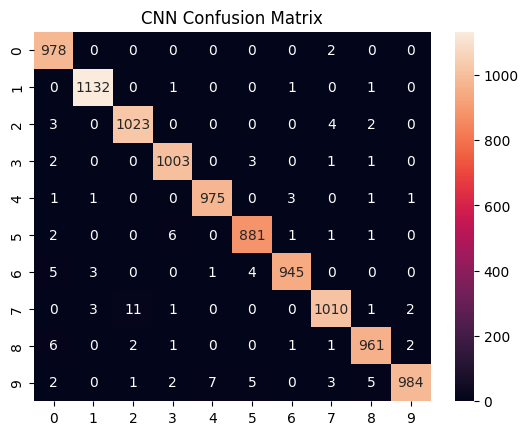

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for images , labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs , 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels , all_preds)

sns.heatmap(cm , annot = True , fmt = 'd')
plt.title("CNN Confusion Matrix")
plt.show()

Conclusion

CNN (Convolutional Neural Network) shows higher accuracy than clustering with an autoencoder. This is because CNN learns from labeled data and better understands the differences between classes. While the autoencoder just learns how to reconstruct images and does not take into account their classes. Therefore, when clustering, the data is separated less accurately.